# PCA-Driven Hitter Profiling with Cluster Analysis and Advanced MLB Metrics

Introduction

Offensive production in baseball is anything but one-dimensional. Hitters vary wildly in contact quality, power output, plate discipline, speed, and overall value, yet traditional statistics often bury those differences under simple averages. This project takes a modern data-science approach to understanding hitter identity by combining dimensionality reduction and unsupervised learning to reveal the underlying structure of MLB offensive profiles.

Using a curated dataset of advanced metrics from FanGraphs ranging from wRC+, OPS, ISO, and OBP to Barrel Percentage, Hard-Hit Rate, Exit Velocity, and Sprint Speed—this analysis applies Principal Component Analysis (PCA) to compress dozens of correlated variables into a smaller set of meaningful components. These components then feed into a k-means clustering model that groups hitters based on their shared performance characteristics rather than traditional positions or surface-level statistics.

The result is a set of clear, analytically grounded hitter archetypes. Each cluster highlights a different offensive style, from elite power producers and above-average regulars to league-average bats, contact-first role players, and replacement-level strugglers. By profiling these clusters and visualizing their normalized performance across key metrics, the project provides a deeper look into what actually differentiates successful MLB hitters from the rest of the league.

In short, this project is an end-to-end demonstration of how machine learning can uncover meaningful player identities, support talent evaluation, and help quantify the nuances of modern MLB offense.


In [39]:
install.packages("remotes")  
remotes::install_github("BillPetti/baseballr")  # latest GitHub version

library(baseballr)
packageVersion("baseballr")

Installing package into 'C:/Users/Defte/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'remotes' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Defte\AppData\Local\Temp\Rtmp0WqInf\downloaded_packages


Skipping install of 'baseballr' from a github remote, the SHA1 (ff996dec) has not changed since last install.
  Use `force = TRUE` to force installation



[1] '1.6.0.9002'

In [40]:
library(tidyverse)
library(rvest)
library(htmlTable)
library(multiUS)
library(ggthemes)
library(RColorBrewer)

In [41]:
library(data.table)


# Load & Clean Data

In [5]:
packageVersion("baseballr")


[1] '1.6.0.9002'

In [6]:
bat_2023 <- fg_batter_leaders(
  age = "",
  pos = "all",
  stats = "bat",
  lg = "all",
  qual = "0",
  startseason = "2023",
  endseason = "2023",
  startdate = "",
  enddate = "",
  month = "0",
  hand = "",
  team = "0",
  pageitems = "10000",
  pagenum = "1",
  ind = "0",
  rost = "0",
  players = "",
  type = "8",
  postseason = "",
  sortdir = "default",
  sortstat = "WAR"
)


glimpse(bat_2023)

Rows: 1,457
Columns: 350
$ Season              <int> 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 20…
$ team_name           <chr> "ATL", "LAD", "LAD", "ATL", "LAA", "TEX", "TEX", "…
$ Bats                <chr> "R", "L", "R", "L", "L", "R", "L", "L", "R", "R", …
$ xMLBAMID            <int> 660670, 518692, 605141, 621566, 660271, 543760, 60…
$ PlayerNameRoute     <chr> "Ronald Acuna Jr.", "Freddie Freeman", "Mookie Bet…
$ PlayerName          <chr> "Ronald Acuña Jr.", "Freddie Freeman", "Mookie Bet…
$ playerid            <int> 18401, 5361, 13611, 14344, 19755, 12533, 13624, 20…
$ Age                 <int> 25, 33, 30, 29, 28, 32, 29, 24, 23, 22, 25, 25, 29…
$ AgeRng              <chr> "25 - 25", "33 - 33", "30 - 30", "29 - 29", "28 - …
$ SeasonMin           <int> 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 20…
$ SeasonMax           <int> 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 20…
$ G                   <int> 159, 161, 152, 162, 135, 162, 119, 162, 158, 155, …
$ AB           

In [7]:
head(bat_2023)

Season,team_name,Bats,xMLBAMID,PlayerNameRoute,PlayerName,playerid,Age,AgeRng,SeasonMin,⋯,pi_KN_pct,pi_vKN,pi_KN-X,pi_KN-Z,pi_wKN,pi_wKN_C,rCPTV,CFraming,rDGV,rDSV
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023,ATL,R,660670,Ronald Acuna Jr.,Ronald Acuña Jr.,18401,25,25 - 25,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023,LAD,L,518692,Freddie Freeman,Freddie Freeman,5361,33,33 - 33,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023,LAD,R,605141,Mookie Betts,Mookie Betts,13611,30,30 - 30,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023,ATL,L,621566,Matt Olson,Matt Olson,14344,29,29 - 29,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023,LAA,L,660271,Shohei Ohtani,Shohei Ohtani,19755,28,28 - 28,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023,TEX,R,543760,Marcus Semien,Marcus Semien,12533,32,32 - 32,2023,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [8]:
bat_2023_clean <- bat_2023 |>
    select(
  Season,
  team_name,
  Bats,
  xMLBAMID,
  PlayerNameRoute,
  PlayerName,
  playerid,
  Age,
  AgeRng,
  SeasonMin,
  SeasonMax,
  G,
  AB,
  PA,
  H,
  `1B`,
  `2B`,
  `3B`,
  HR,
  R,
  RBI,
  BB,
  IBB,
  SO,
  HBP,
  SF,
  SH,
  GDP,
  SB,
  CS,
  AVG,
  GB,
  FB,
  LD,
  IFFB,
  Pitches,
  Balls,
  Strikes,
  IFH,
  BU,
  BUH,
  BB_pct,
  K_pct,
  BB_K,
  OBP,
  SLG,
  OPS,
  ISO,
  BABIP,
  GB_FB,
  LD_pct,
  GB_pct,
  FB_pct,
  IFFB_pct,
  HR_FB,
  IFH_pct,
  BUH_pct,
  TTO_pct,
  wOBA,
  wRAA,
  wRC,
  Batting,
  Fielding,
  Replacement,
  Positional,
  wLeague,
  Defense,
  Offense,
  RAR,
  WAR,
  Dollars,
  BaseRunning,
  Spd,
  wRC_plus,
  wBsR,
  WPA,
  WPA_minus,
  WPA_plus,
  RE24,
  REW,
  pLI,
  PH,
  WPA_LI,
  Clutch,
  Barrel_pct,
  HardHit_pct,
  Oppo_pct,
  EV
)	 |>
    drop_na()

In [9]:
head(bat_2023_clean)

Season,team_name,Bats,xMLBAMID,PlayerNameRoute,PlayerName,playerid,Age,AgeRng,SeasonMin,⋯,RE24,REW,pLI,PH,WPA_LI,Clutch,Barrel_pct,HardHit_pct,Oppo_pct,EV
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023,ATL,R,660670,Ronald Acuna Jr.,Ronald Acuña Jr.,18401,25,25 - 25,2023,⋯,73.5686,7.2083,0.9194,0,6.3047,1.1625,0.1530,0.5516,0.2473,94.7087
2023,LAD,L,518692,Freddie Freeman,Freddie Freeman,5361,33,33 - 33,2023,⋯,71.0980,7.0647,0.9614,0,6.1763,-1.5012,0.1113,0.4223,0.2783,89.9821
2023,LAD,R,605141,Mookie Betts,Mookie Betts,13611,30,30 - 30,2023,⋯,65.1988,6.5664,0.9656,1,6.1147,-0.7243,0.1245,0.4855,0.1826,92.3979
2023,ATL,L,621566,Matt Olson,Matt Olson,14344,29,29 - 29,2023,⋯,66.1810,6.5158,0.9003,0,5.5414,-0.6034,0.1640,0.5551,0.2449,93.7137
2023,TEX,R,543760,Marcus Semien,Marcus Semien,12533,32,32 - 32,2023,⋯,31.9025,3.1452,0.8927,0,2.5908,-1.5326,0.0654,0.3693,0.2018,88.3748
2023,TEX,L,608369,Corey Seager,Corey Seager,13624,29,29 - 29,2023,⋯,49.7610,4.9084,0.9303,0,4.3695,0.3806,0.1519,0.5316,0.2405,93.2699


In [10]:
sum(is.na(bat_2023_clean))

[1] 0

# EDA

In [11]:
library(ggplot2)

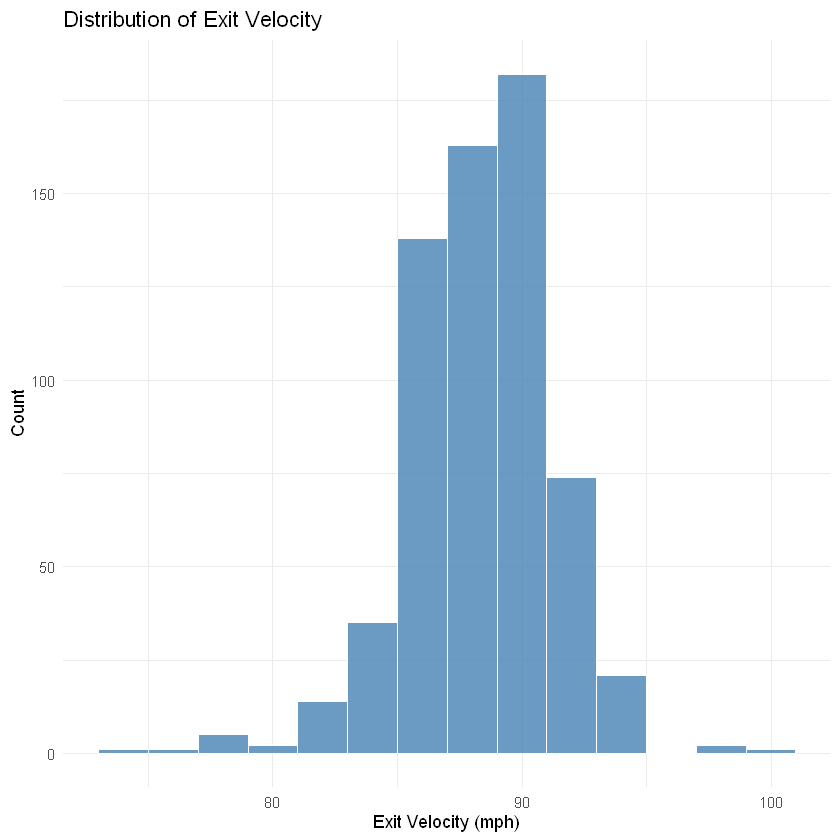

In [12]:
# Distribution of Exit Velocity

plot1 <- ggplot(bat_2023_clean, aes(x = EV)) +
  geom_histogram(binwidth = 2, fill = "steelblue", color = "white", alpha = 0.8) +
  labs(
    title = "Distribution of Exit Velocity",
    x = "Exit Velocity (mph)",
    y = "Count"
  ) +
  theme_minimal()

  ggsave("DistEV.png", plot1, width = 7, height = 5, dpi = 300)
  print(plot1)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


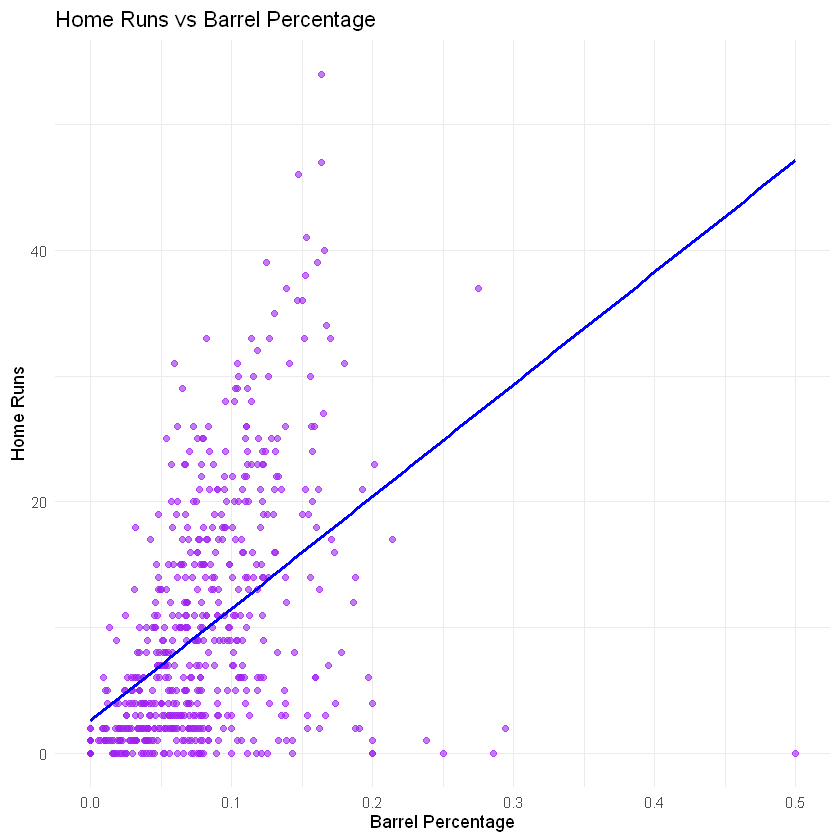

In [13]:
# Home Runs vs Barrel Percentage

plot2 <- ggplot(bat_2023_clean, aes(x = Barrel_pct, y = HR)) +
  geom_point(alpha = 0.6, color = "purple") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  labs(
    title = "Home Runs vs Barrel Percentage",
    x = "Barrel Percentage",
    y = "Home Runs"
  ) +
  theme_minimal()

  ggsave("HRvsBarrel.png", plot2, width = 7, height = 5, dpi = 300)
  print(plot2)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


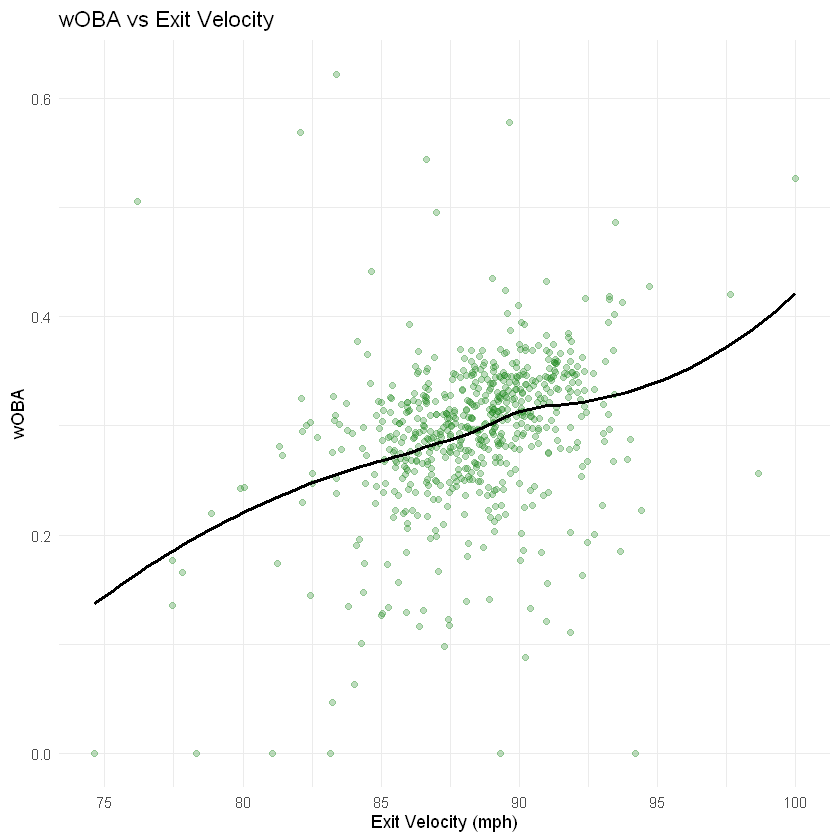

In [14]:
# wOBA vs Exit Velocity

plot3 <- ggplot(bat_2023_clean, aes(x = EV, y = wOBA)) +
  geom_point(alpha = 0.3, color = "forestgreen") +
  geom_smooth(method = "loess", se = FALSE, color = "black") +
  labs(
    title = "wOBA vs Exit Velocity",
    x = "Exit Velocity (mph)",
    y = "wOBA"
  ) +
  theme_minimal()

  ggsave("wOBAvsEV.png", plot3, width = 7, height = 5, dpi = 300)
  print(plot3)

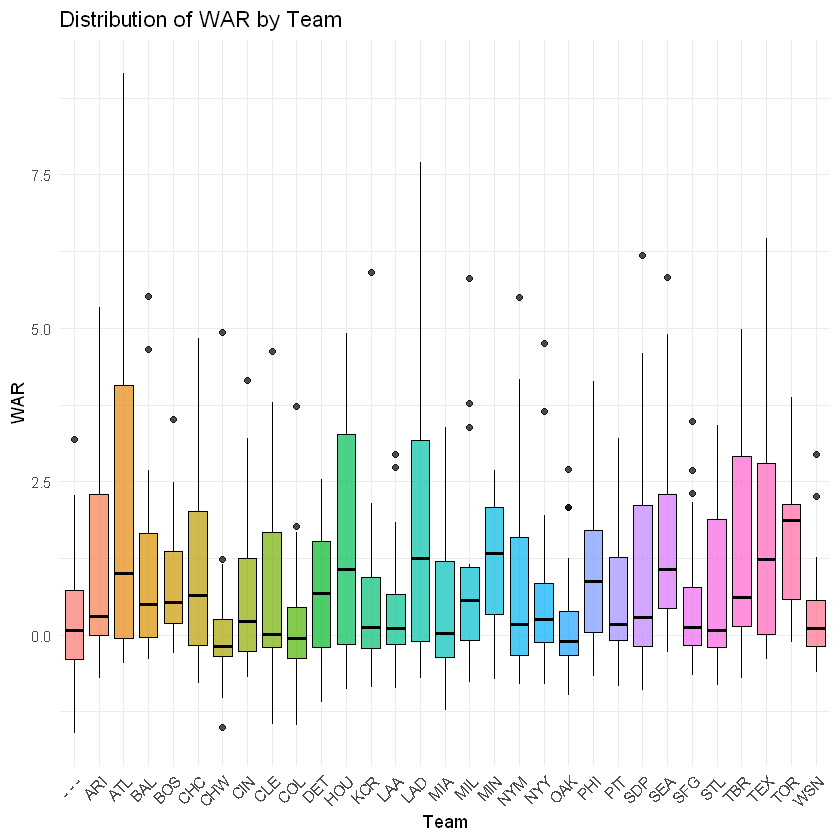

In [15]:
# Distribution of WAR by Team

 plot4 <- ggplot(bat_2023_clean, aes(x = team_name, y = WAR, fill = team_name)) +
  geom_boxplot(alpha = 0.7, color = "black") +
  labs(
    title = "Distribution of WAR by Team",
    x = "Team",
    y = "WAR"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) 
  
  ggsave("DWarTeam.png", plot4, width = 7, height = 5, dpi = 300)
  print(plot4)

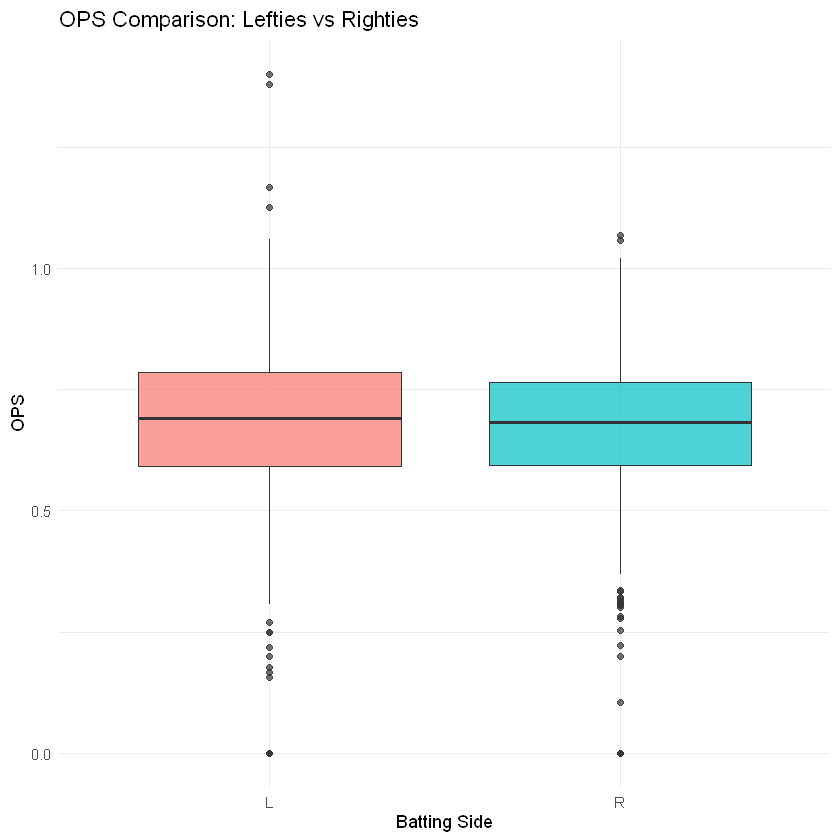

In [16]:
plot5 <- bat_2023_clean |> 
  filter(Bats %in% c("L", "R")) |> 
  ggplot(aes(x = Bats, y = OPS, fill = Bats)) +
  geom_boxplot(alpha = 0.7) +
  labs(
    title = "OPS Comparison: Lefties vs Righties",
    x = "Batting Side",
    y = "OPS"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

  ggsave("LvsROPS.png", plot5, width = 7, height = 5, dpi = 300)
  print(plot5)

Exploratory Data Analysis Summary
1. OPS Comparison: Lefties vs Righties

The boxplot comparing OPS for left-handed (L) and right-handed (R) hitters shows that both groups perform similarly overall.

Lefties display slightly more spread with a few extreme high and low values.

Righties are more compact, but the medians are nearly identical.

Interpretation:
Batting side alone does not meaningfully separate hitter performance. OPS distributions overlap heavily, indicating handedness is not a strong predictor of offensive output.

2. wOBA vs Exit Velocity

The scatterplot with a smooth trend line shows a clear upward relationship:

wOBA increases steadily with exit velocity.

Below 90 mph, performance outcomes are volatile and inconsistent.

Above 95 mph, wOBA trends sharply higher.

Interpretation:
Quality of contact matters. Exit velocity strongly influences offensive value, and harder-hit balls reliably produce better outcomes.

3. Home Runs vs Barrel Percentage

This scatterplot reveals a strong linear relationship:

Players with higher barrel percentages hit noticeably more home runs.

Home run totals climb rapidly around the 10 to 15 percent barrel range.

Extremely high barrel hitters accumulate power quickly.

Interpretation:
Barrel percentage is one of the best single indicators of home run production. Optimal combinations of launch angle and exit velocity drive power outcomes.

4. Distribution of Exit Velocity

The histogram shows a near-normal distribution centered around typical MLB contact strength:

Most hitters cluster between 87 and 92 mph.

A few light hitters sit in the low 80s.

A small group of elite hitters reaches exit velocities near or above 100 mph.

Interpretation:
Exit velocity clusters tightly around league-average values with notable outliers at both ends. This underscores why standout contact-quality metrics are so influential.

Overall Insight

Across all four plots, several consistent themes appear:

Contact quality (EV, Barrel%) drives offensive value.

OPS does not meaningfully differ by handedness.

Power metrics scale directly with barrel ability.

Hitter differences emerge more from approach and batted-ball profile than from simple traits like batting side.

# Fit for PCA

Data Description

This dataset contains a comprehensive set of Major League Baseball hitter statistics derived from FanGraphs and Statcast. The variables cover traditional results, plate discipline, batted-ball characteristics, advanced run-value metrics, and underlying contact quality. Together they form a complete quantitative profile of offensive performance.

1. Traditional Counting Stats

These metrics describe raw outcomes accumulated over the season.

G – Games played

PA – Plate appearances

AB – At-bats

H, 1B, 2B, 3B, HR – Hits by type (singles, doubles, triples, home runs)

R – Runs scored

RBI – Runs batted in

SB, CS – Stolen bases and times caught stealing

BB, IBB – Walks and intentional walks

SO – Strikeouts

HBP – Hit-by-pitch

SF, SH – Sacrifice flies / bunts

GDP – Ground into double play

2. Plate Discipline & Swing Outcome Stats

These reflect approach, patience, and swing tendencies.

Pitches, Balls, Strikes – Total pitches faced and breakdown

BB_pct – Walk rate

K_pct – Strikeout rate

BB_K – Walk-to-strikeout ratio

TTO_pct – Three-true-outcome percentage (BB + SO + HR)

3. Rate Stats (Standard Sabermetrics)

These normalize performance independent of raw opportunities.

AVG – Batting average

OBP – On-base percentage

SLG – Slugging percentage

OPS – On-base plus slugging

ISO – Isolated power (SLG − AVG)

BABIP – Batting average on balls in play

4. Batted-Ball Profile

These measure how the player hits the ball: distribution of contact types.

GB, FB, LD, IFFB – Ground balls, fly balls, line drives, infield fly balls

GB_FB – Ground ball to fly ball ratio

GB_pct, FB_pct, LD_pct, IFFB_pct – Percent of each batted-ball type

HR_FB – Home runs per fly ball

IFH, IFH_pct – Infield hits and percent of contact that becomes IFH

BU, BUH, BUH_pct – Bunts, bunt hits, bunt hit rate

Oppo_pct – Opposite-field contact percentage

5. Statcast Quality-of-Contact Metrics

These measure the underlying skill behind outcomes.

EV – Average exit velocity

HardHit_pct – Percent of batted balls hit 95+ mph

Barrel_pct – Percent of batted balls classified as “barrels”
(optimal combination of launch angle and exit velocity)

These metrics reflect how dangerous a hitter is independent of luck or defense.

6. Advanced Run-Value & Context-Adjusted Metrics

These measure overall offensive value and contribution above average.

wOBA – Weighted On-Base Average

wRAA – Weighted Runs Above Average

wRC – Weighted Runs Created

wRC_plus – League and park-adjusted version of wRC

Batting – FanGraphs batting runs

Offense – Total offensive runs (batting + baserunning)

BaseRunning, wBsR – Baserunning value

RAR – Runs Above Replacement

WAR – Wins Above Replacement

Dollars – Estimated free-agent value in dollars

wLeague – League-adjusted performance

7. Fielding, Position, and Replacement Metrics

These help situate offensive value relative to defensive role.

Fielding – Defensive contribution

Positional – Positional adjustment in WAR

Replacement – Replacement-level baseline adjustment

8. Win Probability & Leverage Metrics

These capture performance in high-impact situations.

WPA, WPA_plus, WPA_minus – Win Probability Added (positive, negative, net)

RE24 – Run expectancy added

REW – Wins created through RE24

pLI – Average leverage index (pressure situations)

WPA_LI – Context-neutral WPA

Clutch – Performance in high-leverage situations

PH – Pinch-hitting appearances

Summary

This dataset blends traditional results, modern analytical metrics, and Statcast contact-quality data to create an exhaustive description of MLB hitters. The combination of outcome-based stats (like HR, OBP, WAR), underlying skill indicators (EV, Barrel%), and situational run-value metrics (WPA, RE24) provides a strong foundation for dimensionality reduction, clustering, and player profiling.

In [18]:
pca_fit <- prcomp(x = bat_2023_clean |>
    select(
   G,
  AB,
  PA,
  H,
  `1B`,
  `2B`,
  `3B`,
  HR,
  R,
  RBI,
  BB,
  IBB,
  SO,
  HBP,
  SF,
  SH,
  GDP,
  SB,
  CS,
  AVG,
  GB,
  FB,
  LD,
  IFFB,
  Pitches,
  Balls,
  Strikes,
  IFH,
  BU,
  BUH,
  BB_pct,
  K_pct,
  BB_K,
  OBP,
  SLG,
  OPS,
  ISO,
  BABIP,
  GB_FB,
  LD_pct,
  GB_pct,
  FB_pct,
  IFFB_pct,
  HR_FB,
  IFH_pct,
  BUH_pct,
  TTO_pct,
  wOBA,
  wRAA,
  wRC,
  Batting,
  Fielding,
  Replacement,
  Positional,
  wLeague,
  Defense,
  Offense,
  RAR,
  WAR,
  Dollars,
  BaseRunning,
  Spd,
  wRC_plus,
  wBsR,
  WPA,
  WPA_minus,
  WPA_plus,
  RE24,
  REW,
  pLI,
  PH,
  WPA_LI,
  Clutch,
  Barrel_pct,
  HardHit_pct,
  Oppo_pct,
  EV), 
    scale = TRUE, center = TRUE)

summary(pca_fit)

pca_df = as.data.frame(pca_fit$x)

Importance of components:
                          PC1     PC2     PC3     PC4     PC5     PC6    PC7
Standard deviation     5.5876 2.77245 2.25335 2.09335 1.79738 1.59386 1.4815
Proportion of Variance 0.4055 0.09982 0.06594 0.05691 0.04196 0.03299 0.0285
Cumulative Proportion  0.4055 0.50530 0.57124 0.62815 0.67010 0.70310 0.7316
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     1.39096 1.25970 1.23317 1.14896 1.06978 1.04975 1.00400
Proportion of Variance 0.02513 0.02061 0.01975 0.01714 0.01486 0.01431 0.01309
Cumulative Proportion  0.75673 0.77733 0.79708 0.81423 0.82909 0.84340 0.85649
                          PC15    PC16    PC17    PC18    PC19    PC20    PC21
Standard deviation     0.97745 0.96064 0.93171 0.89987 0.86127 0.82358 0.80123
Proportion of Variance 0.01241 0.01198 0.01127 0.01052 0.00963 0.00881 0.00834
Cumulative Proportion  0.86890 0.88089 0.89216 0.90268 0.91231 0.92112 0.92946
                          PC22    

In [45]:
pca_var <- pca_fit$sdev^2

pca_percent <- round(pca_var / sum(pca_var) * 100, 2)

print(pca_percent)

 [1] 40.55  9.98  6.59  5.69  4.20  3.30  2.85  2.51  2.06  1.97  1.71  1.49
[13]  1.43  1.31  1.24  1.20  1.13  1.05  0.96  0.88  0.83  0.77  0.68  0.59
[25]  0.58  0.47  0.46  0.42  0.39  0.32  0.32  0.25  0.23  0.21  0.21  0.18
[37]  0.17  0.16  0.13  0.09  0.08  0.05  0.05  0.04  0.04  0.03  0.03  0.02
[49]  0.02  0.02  0.01  0.01  0.01  0.00  0.00  0.00  0.00  0.00  0.00  0.00
[61]  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
[73]  0.00  0.00  0.00  0.00  0.00


In [19]:
print(pca_fit)

Standard deviations (1, .., p=77):
 [1] 5.587600e+00 2.772446e+00 2.253355e+00 2.093346e+00 1.797378e+00
 [6] 1.593865e+00 1.481459e+00 1.390958e+00 1.259699e+00 1.233166e+00
[11] 1.148960e+00 1.069780e+00 1.049746e+00 1.004002e+00 9.774503e-01
[16] 9.606394e-01 9.317072e-01 8.998674e-01 8.612666e-01 8.235838e-01
[21] 8.012259e-01 7.691137e-01 7.215357e-01 6.753724e-01 6.706228e-01
[26] 6.023029e-01 5.945246e-01 5.705774e-01 5.460375e-01 4.977303e-01
[31] 4.944340e-01 4.352563e-01 4.180492e-01 4.050202e-01 3.999872e-01
[36] 3.746923e-01 3.649619e-01 3.458553e-01 3.122151e-01 2.658606e-01
[41] 2.551281e-01 2.010441e-01 1.940429e-01 1.823231e-01 1.650862e-01
[46] 1.580219e-01 1.541139e-01 1.266746e-01 1.214529e-01 1.099918e-01
[51] 1.061203e-01 9.995088e-02 7.906042e-02 5.465764e-02 4.592417e-02
[56] 4.271621e-02 2.991165e-02 2.551864e-02 2.293260e-02 1.942841e-02
[61] 3.937127e-03 1.658618e-03 3.159094e-04 2.917759e-04 2.291521e-04
[66] 1.925763e-04 1.602772e-05 1.180281e-05 7.998107e-0

## PCA Component Interpretation

The PCA results indicate that the first several components capture most of the meaningful variation in MLB hitter performance. These components summarize broad offensive profiles while reducing noise from highly correlated stats.

---

### **PC1 (40.6 percent of variance)**  
**Overall Offensive Quality**

This is the dominant axis in the dataset. It captures:

- Power production (ISO, SLG, HR)
- Contact quality (EV, Barrel%, HardHit%)
- Run creation (wOBA, wRC+, WAR)

**High PC1:** elite, well-rounded hitters  
**Low PC1:** weak or low-impact offensive players

---

### **PC2 (10 percent of variance)**  
**Plate Discipline & Approach**

This component distinguishes hitters by patience and swing decisions:

- High PC2: patient hitters with strong BB% and good approach  
- Low PC2: aggressive hitters or high-strikeout bats

---

### **PC3 (6.6 percent of variance)**  
**Batted-Ball Profile**

This axis splits players by how they hit the ball:

- Groundball vs flyball tendencies  
- Line-drive frequency  
- General contact style

It reflects underlying mechanical or approach differences.

---

### **PC4–PC5 (about 10 percent combined)**  
**Secondary Contextual Factors**

These capture more specific traits:

- Situational value (WPA, RE24)  
- Baserunning and speed  
- Positional or fielding context

They help distinguish player archetypes beyond simple power/contact metrics.

---

### **PC6–PC10 (2–3 percent each)**  
**Niche Tendencies**

These components isolate smaller-scale differences:

- Opposite-field tendency (Oppo%)  
- Infield hit skill (IFH%)  
- Bunt value  
- Subtle approach quirks

Useful for fine-grained clustering, but not primary drivers of performance.

---

### **PC11 and higher (1–2 percent each)**  
**Noise & Minor Variation**

These contain little meaningful signal. They represent statistical noise or extremely narrow traits not crucial for cluster formation.

---

## **Overall Summary**

Using the **first 8 principal components** preserves roughly **76 percent** of the total variance. These components capture all core offensive structure:

- Power  
- Plate discipline  
- Contact and batted-ball profile  
- Secondary value traits  

This makes PCA space an excellent foundation for **clustering MLB hitters into meaningful, interpretable archetypes** while filtering out noisy or redundant dimensions.


## PC1 – Overall Playing Time & Production Load

**Big (negative) loadings on:**

- G, AB, PA  
- R, RBI, wRC  
- Replacement, wLeague  
- Pitches, Balls, Strikes  
- Also many counting stats like H, BB, SF, etc.

**Interpretation:**  
PC1 is basically a **“volume & overall contribution”** axis.

- High magnitude: everyday players who rack up PA, runs, RBI, and overall value  
- Low magnitude: part-timers, bench bats, callups  

This reflects **how much a player actually plays and contributes in aggregate**.

---

## PC2 – Power / Impact vs Small Ball

**Strong positive loadings on:**

- SLG, ISO, HR_FB  
- wOBA, wRAA, Batting, Offense, wRC+  
- WPA, RE24, WPA_LI  
- HardHit%, Barrel-type metrics, EV (modestly positive)

**Moderately negative on:**

- SH, BU, BUH  
- GB_pct, GB/FB  
- Other “scrappy / small-ball” profile stats

**Interpretation:**  
PC2 is a **“power & impact”** axis.

- High PC2: extra-base power, hard contact, strong run creation, high WPA/RE24  
- Low PC2: more small-ball, bunting, ground-heavy profiles with lower impact  

This captures **how dangerous a bat is when it does something**.

---

## PC3 – Speed & Baserunning vs Power/K

**Big positive loadings on:**

- SB, CS  
- Spd, BaseRunning, wBsR  
- Some contribution from triples, bunts, opposite-field contact

**Negative loadings on:**

- Barrel_pct, HardHit_pct, EV  
- FB_pct, HR  
- TTO_pct

**Interpretation:**  
PC3 is **“speed / baserunning vs power slugger.”**

- High PC3: fast, run-focused players, good baserunners, more speed value  
- Low PC3: slower power bats, more barrels, more HR/FB, more K / true outcomes  

This axis essentially **splits “rabbits” vs “tanks.”**

---

## PC4 – Line-Drive / BABIP Hitters vs Total Run Value

**Big positive loadings on:**

- AVG, BABIP  
- LD_pct  
- OBP, wOBA, OPS, wRC_plus  
- Line-drive / contact-quality profile

**Big negative loadings on:**

- Batting, Offense  
- RE24, WPA  
- WAR, RAR (cumulative run metrics)

**Interpretation:**  
PC4 is **“per-PA contact quality / line-drive success vs overall compiled value.”**

- High PC4: hitters with strong AVG/OBP/BABIP and more line drives per PA  
- Low PC4: players whose **total run impact** (WPA/RE24/WAR) is high, but not driven primarily by BABIP/AVG  

This axis separates **“pretty stat-line hitters” vs “total impact in context.”**

---

## PC5 – High-Contact Ground/Gap Hitters vs TTO Power Guys

**Big positive loadings on:**

- BB_K, BB_pct  
- GB_FB, GB_pct  
- GDP  
- Some AVG / LD_pct

So: more walks relative to strikeouts, more groundballs, more contact/gap-style hitting.

**Big negative loadings on:**

- K_pct, TTO_pct  
- ISO, HR_FB  
- Barrel_pct, EV, HardHit_pct

**Interpretation:**  
PC5 is **“contact-oriented groundball/gap profile vs three-true-outcome power bat.”**

- High PC5: low K, decent BB/K, more grounders, fewer barrels, less ISO  
- Low PC5: high Ks, high HR/FB, more barrels, TTO-heavy sluggers  

This is essentially the **Luis Arraez / slap-contact** side vs the **Joey Gallo archetype**.

---

## PCs 6–10 (Very Short Summary)

These components are more niche and noisy, but roughly:

- **PC6:** mix of GB vs FB structure plus IFFB, with some fielding/positional influence  
- **PC7:** strongly tied to **defense, positional value, and GB/FB**, shaping where a player fields and how much defensive value they add  
- **PC8:** another refinement of **plate discipline style**, combining walks, strikeouts, BB_K, and TTO_pct  
- **PC9–PC10:** more subtle structure around **LD%, BABIP, IFH, bunting**, and situational quirks



# Kmeans Clustering

In [ ]:
set.seed(42) # for Jackie Robinson

k <- 5  

km <- kmeans(pca_df[, 1:8], centers = k, nstart = 20)

pca_df$cluster <- as.factor(km$cluster)

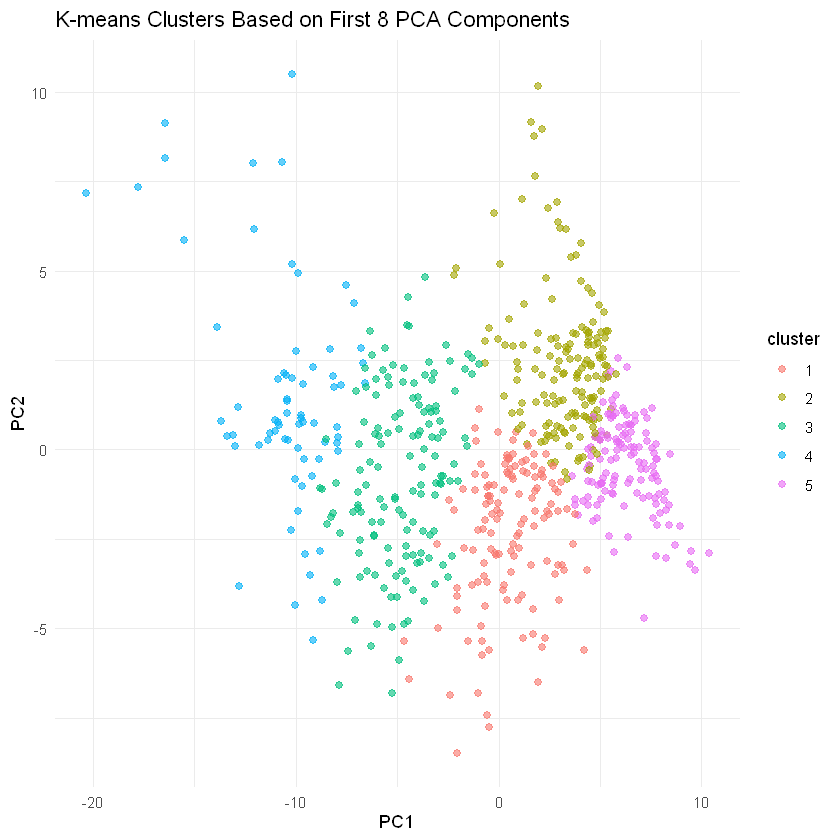

In [43]:
 clusterplot <- ggplot(pca_df, aes(x = PC1, y = PC2, color = cluster)) +
  geom_point(alpha = 0.6, size = 2) +
  labs(
    title = "K-means Clusters Based on First 8 PCA Components",
    x = "PC1",
    y = "PC2"
  ) +
  theme_minimal()

  ggsave("KMeansClusters.png", clusterplot, width = 7, height = 5, dpi = 300)
  print(clusterplot)

In [22]:
df_clustered <- bat_2023_clean |> 
  filter(complete.cases(select(bat_2023_clean, where(is.numeric)))) |>  # matches PCA rows
  mutate(cluster = pca_df$cluster)

  

In [26]:
cluster_profile <- df_clustered |> 
  group_by(cluster) |> 
  summarize(
    n_players = n(),
    avg_OPS = mean(OPS, na.rm = TRUE),
    avg_wOBA = mean(wOBA, na.rm = TRUE),
    avg_wRC_plus = mean(wRC_plus, na.rm = TRUE),
    avg_Barrel = mean(Barrel_pct, na.rm = TRUE),
    avg_HardHit = mean(HardHit_pct, na.rm = TRUE),
    avg_EV = mean(EV, na.rm = TRUE),
    avg_ISO = mean(ISO, na.rm = TRUE),
    avg_SLG = mean(SLG, na.rm = TRUE),
    avg_OBP = mean(OBP, na.rm = TRUE),
    avg_K_rate = mean(K_pct, na.rm = TRUE),
    avg_BB_rate = mean(BB_pct, na.rm = TRUE),
    avg_Speed = mean(Spd, na.rm = TRUE),
    avg_WAR = mean(WAR, na.rm = TRUE),
    .groups = "drop"
  )

In [27]:
library(knitr)
kable(cluster_profile, digits = 3, caption = "Cluster Profiles")



Table: Cluster Profiles

|cluster | n_players| avg_OPS| avg_wOBA| avg_wRC_plus| avg_Barrel| avg_HardHit| avg_EV| avg_ISO| avg_SLG| avg_OBP| avg_K_rate| avg_BB_rate| avg_Speed| avg_WAR|
|:-------|---------:|-------:|--------:|------------:|----------:|-----------:|------:|-------:|-------:|-------:|----------:|-----------:|---------:|-------:|
|1       |       133|   0.646|    0.284|       76.368|      0.056|       0.347| 87.708|   0.121|   0.352|   0.294|      0.229|       0.073|     4.376|   0.218|
|2       |       160|   0.740|    0.323|      103.440|      0.078|       0.374| 88.120|   0.162|   0.413|   0.327|      0.257|       0.090|     3.623|   0.208|
|3       |       144|   0.759|    0.328|      106.468|      0.092|       0.415| 89.423|   0.179|   0.433|   0.325|      0.233|       0.085|     4.035|   1.731|
|4       |        70|   0.843|    0.360|      128.878|      0.104|       0.434| 90.313|   0.211|   0.487|   0.356|      0.201|       0.103|     4.745|   4.173|
|5       |   

# Hitter Cluster Profiles

## Cluster 4: **Elite Power Hitters**
**Metrics**
- OPS: .843  
- wRC+: 128  
- HardHit%: 43.4 percent  
- EV: 90.3 mph  
- ISO: .211  
- WAR: 4.17   
- Speed: Above average  

**Identity**  
Middle of the order nuclear options. High contact quality, big power, real production, and sneaky speed. Think Mookie Betts, Freddie Freeman, Matt Olson territory.

**Summary**  
These are franchise hitters. Build everything around them.

---

## Cluster 3: **Strong Everyday Regulars**
**Metrics**
- OPS: .759  
- wRC+: 106  
- Barrel%: 9.2 percent  
- HardHit%: 41.5 percent  
- EV: 89.4 mph  
- WAR: 1.73  

**Identity**  
Solid everyday players with legit pop, respectable discipline, and good contact quality.

**Summary**  
Start on most teams and sometimes make All-Star noise.

---

## Cluster 2: **Average MLB Hitters**
**Metrics**
- OPS: .740  
- wRC+: 103  
- Barrel%: 7.8 percent  
- EV: 88.1 mph  
- ISO: .162  

**Identity**  
Prototype “league-average hitter.” Some pop, some swing-and-miss, nothing dramatic.

**Summary**  
The middle class. Useful, stable, not terrifying.

---

## Cluster 1: **Low-Impact Contact and Glove Types**
**Metrics**
- OPS: .646  
- wRC+: 76  
- ISO: .121  
- HardHit%: 34.7 percent  
- WAR: Barely above 0  

**Identity**  
Platoon bats, utility players, glove-first defenders, and contact-only hitters.

**Summary**  
Bench pieces or niche role players. Replaceable.

---

## Cluster 5: **Replacement-Level Strugglers**
**Metrics**
- OPS: .430  
- wRC+: 18  
- ISO: .066  
- EV: 86.8 mph  
- WAR: -0.30  
- K%: 30 percent  
- OBP: .214 (lowest)  

**Identity**  
The “why is he still getting ABs” crowd. Pitchers hitting in disguise, rookies drowning, defenders who don’t defend. Twitter demons.

**Summary**  
Actively harmful to your lineup.

---

## Final Cluster Labels

| Cluster | Name                             |
|--------|----------------------------------|
| 4      | Elite Power Hitters              |
| 3      | Strong Everyday Regulars         |
| 2      | Average MLB Hitters              |
| 1      | Low-Impact Contact and Glove Types |
| 5      | Replacement-Level Strugglers     |


In [34]:
metrics <- c(
  "avg_OPS",
  "avg_wOBA",
  "avg_wRC_plus",
  "avg_Barrel",
  "avg_HardHit",
  "avg_EV",
  "avg_ISO",
  "avg_SLG",
  "avg_OBP",
  "avg_K_rate",
  "avg_BB_rate",
  "avg_Speed",
  "avg_WAR"
)



profile_long <- cluster_profile |>
  mutate(cluster = factor(cluster)) |>
  pivot_longer(
    cols = all_of(metrics),
    names_to = "metric",
    values_to = "value"
  )

profile_long_norm <- profile_long |>
  group_by(metric) |>
  mutate(
    value_norm = (value - min(value)) / (max(value) - min(value))
  ) |>
  ungroup()



In [36]:
cluster_labels <- c(
  "1" = "Low-Impact Contact / Glove Types",
  "2" = "League-Average Hitters",
  "3" = "Above-Average Regulars",
  "4" = "Elite Power Hitters",
  "5" = "Replacement-Level Strugglers"
)

df_clustered <- df_clustered |>
  mutate(cluster_label = cluster_labels[cluster])


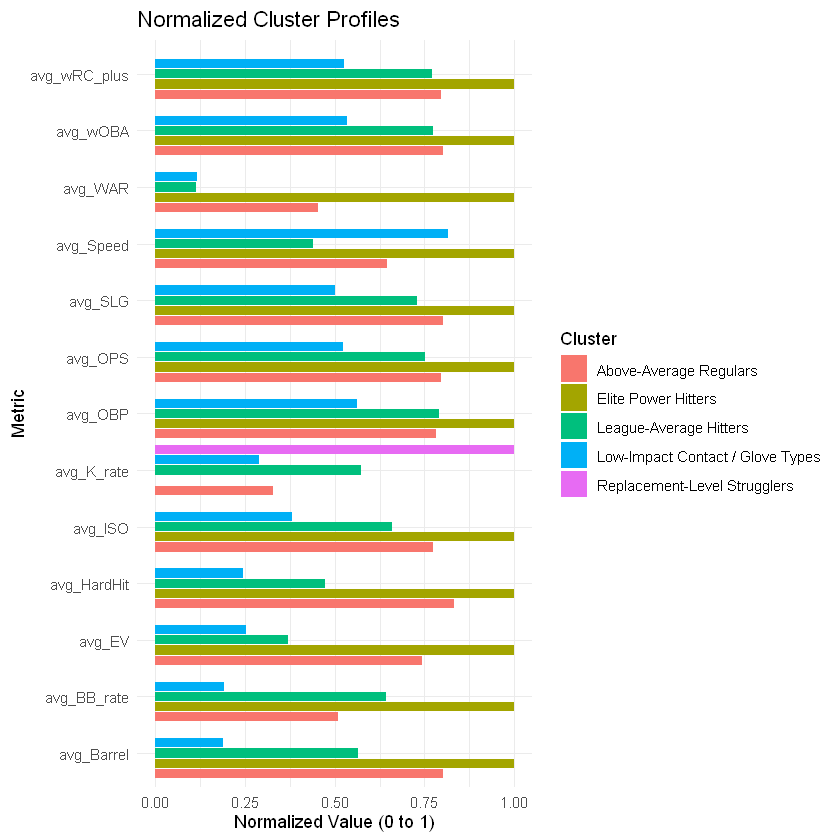

In [44]:
profile_long_norm <- profile_long_norm |>
  mutate(cluster_label = cluster_labels[as.character(cluster)])

 NormProfilesPlot <- ggplot(profile_long_norm, aes(x = metric, y = value_norm, fill = cluster_label)) +
  geom_col(position = "dodge2") +
  coord_flip() +
  labs(
    title = "Normalized Cluster Profiles",
    x = "Metric",
    y = "Normalized Value (0 to 1)",
    fill = "Cluster"
  ) +
  theme_minimal()
  ggsave("NormalizedClusterProfiles.png", NormProfilesPlot, width = 10, height = 6, dpi = 300)
  print(NormProfilesPlot)

Conclusion

This project identifies the core dimensions that define modern MLB hitters by combining EDA, PCA, and clustering. The analysis shows that contact quality, power, plate discipline, and batted-ball profile drive most of the meaningful variation in performance, while simpler traits like handedness provide little predictive value. By reducing the data to key components and grouping hitters by shared characteristics, the project uncovers clear offensive archetypes and offers a structured way to compare players beyond surface-level stats.